# Generative AI Applications Project
* **Gene Foxwell**

## Overview

This project looks at how a Generative Pretrained Transformer Model (GPT) can be used to solve Reinforcement Learning Problems. The idea is based on the Decision Transformers paper (PAPER). We will use the Human Relocate Data from Minari's DR4RL section. Further information on the Relocate data can be found here (PAPER). The relocate problem was originally introduced here (PAPER). 

The basic problem is to train virtual 24 DoF robotic hand to pick up a ball from one location and move it to another.

We'll attack this problem in the following sequence:

* Build a GPT Model that we can use with a Decision Transformer.
* We'll build an implementation of the Decision Transformer Algorithm.
* We'll train the algorithm on the Human generated data for the Relocate the problem.
* Summary of results.

Let's get started...

## Transformer Model

We'll build our transformer model based on the architecture described in (ATTENTION PAPER) as well as examples from Udacity's course work.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from collections import deque

import minari
import gymnasium as gym
import gymnasium_robotics

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


In [2]:
# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )
        self.K_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )
        self.V_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(
            torch.ones(config["context_size"], config["context_size"])
        )
        self.register_buffer("casual_attention_mask", casual_attention_mask)

    def forward(self, input):  # (B, C, embedding_dim)
        batch_size, tokens_num, embedding_dim = input.shape
        Q = self.Q_weights(input)  # (B, C, head_size)
        K = self.K_weights(input)  # (B, C, head_size)
        V = self.V_weights(input)  # (B, C, head_size)

        # Matrix Multiplay Q x K transpose to get the dot product of the query vectors with the key vectors
        attention_scores = Q @ K.transpose(1, 2)  # (B, C, C)

        # scale attention scores, scalled by square root of the dimensionality of the key vectors
        attention_scores = attention_scores / (K.shape[-1] ** 0.5)
        
        # mask the attention scores
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0, -torch.inf
        )

        # calculate softmax values
        attention_scores = torch.softmax(attention_scores, dim=-1)

        # apply dropout for regularization
        attention_scores = self.dropout(attention_scores)

        # multiply attention scores by the value function.
        return attention_scores @ V  # (B, C, head_size)

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        # initialize the individual AttentionHead objects
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        # Feedforward connection for after the attention heads
        self.linear = nn.Linear(config["embed_dim"], config["embed_dim"])

        # Dropout regularization.
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        # execute heads in ||
        heads_outputs = [head(input) for head in self.heads]

        # concatenate the outputs into a single tensor
        scores_change = torch.cat(heads_outputs, dim=-1)

        # run the results through a feed forward network.
        scores_change = self.linear(scores_change)

        # regularization and return results
        return self.dropout(scores_change)

In [5]:
class FeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.linear_layers = nn.Sequential(
            nn.Linear(config["embed_dim"], config["embed_dim"] * 4),
            nn.GELU(),
            nn.Linear(config["embed_dim"] * 4, config["embed_dim"]),
            nn.Dropout(config["dropout_rate"]),
        )

    def forward(self, input):
        return self.linear_layers(input)

In [6]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["embed_dim"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["embed_dim"])

    def forward(self, input):
        residual = input
        x = self.multi_head(self.layer_norm_1(input))
        x = x + residual

        residual = x
        x = self.feed_forward(self.layer_norm_2(x))
        return x + residual

In [7]:
class TransformerModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        self.layer_norm = nn.LayerNorm(config["embed_dim"])


    def forward(self, input_embeddings):
        """
        Forward step for the transformer model. The DecisionTransformer already handles embeddings and positional encodings.
        We are simply making predictions using the AttentionHeads and returning the final hidden layer.
        """
        
        # Pass the embeddings through the stacked Transformer blocks
        x = self.layers(input_embeddings)
        
        # Apply the final layer normalization
        return self.layer_norm(x)

## Decision Transformer

We'll base our implementation of the Decision Transformer based on the original papers github repo found here: (https://github.com/kzl/decision-transformer)

In [8]:
class DecisionTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        # size of the hidden layer
        self.hidden_size = config["embed_dim"]

        # maximum number of timetimes in an episode
        max_ep_length = config["max_ep_length"]
        
        # dimension of the state space
        self.state_dim = config["state_dim"]

        # dimension of the action space.
        self.action_dim = config["action_dim"]

        # embedding layers for timestamps, returns, states, and actions (t,r,s,a)
        # remember, at each time timestamp, we have a triple:
        #   r = expected return
        #   s = state
        #   a = action
        self.embed_timestep = nn.Embedding(max_ep_length, self.hidden_size)
        self.embed_return = nn.Linear(1, self.hidden_size)
        self.embed_state = nn.Linear(self.state_dim, self.hidden_size)
        self.embed_action = nn.Linear(self.action_dim, self.hidden_size)

        # Normalization of the embedding layers
        self.embed_ln = nn.LayerNorm(self.hidden_size)
        
        # action prediction layer
        self.predict_action = nn.Linear(self.hidden_size, self.action_dim)

        # create an instance of the transformer model
        # this will be used to generate the next steps in the sequence.
        self.transformer = TransformerModel(config)

    def forward(self, states, actions, returns_to_go, timesteps):
        """
        Generate the next action using the previous Returns, States, Actions, and Timestamps.
        """
        batch_size, seq_length = states.shape[0], states.shape[1]
        
        pos_embedding = self.embed_timestep(timesteps)
        
        state_embeddings = self.embed_state(states) + pos_embedding
        action_embeddings = self.embed_action(actions) + pos_embedding
        returns_embeddings = self.embed_return(returns_to_go) + pos_embedding
        
        stacked_inputs = torch.stack(
            (returns_embeddings, state_embeddings, action_embeddings), dim=1
        ).permute(0, 2, 1, 3).reshape(batch_size, 3*seq_length, self.hidden_size)
        
        input_embeddings = self.embed_ln(stacked_inputs)
        
        hidden_states = self.transformer(input_embeddings)
        
        action_logits = self.predict_action(hidden_states[:, 1::3, :])
    
        return torch.tanh(action_logits)


## ADROIT Hand Relocate Problem

We are focusing on the ADROIT Relocation problem. In this problem we will drain a robotic hand to find a ball, pick it up, and then drop it off at another location. We will train this hand using human generated data provided by Minari. Our agent will be based on the DecisionTransformer approach above - autoregressively outputing the policy needed to solve the environment.

Ultimately, we want to see how well the resulting Agent can generalize based on training from human data alone.

### Action Space

The ADROIT Hand has 24 Degrees of Freedom. The full action space is documented here: https://robotics.farama.org/envs/adroit_hand/adroit_relocate/

The action space has 30 dimensions. 24 dimensions for controlling the actuators of the hand, and 6 dimenions for controlling the position of the hand in the environment.

Inputs to the hands are scaled between to fall in the range [-1, 1]

### Observation Space

The observation space for this system has 39 dimenions. 30 dimensions for describing the state of the arms actuator and the position / rotatation of the arm itself. The final 9 dimensions describe the different in location between the palm of the hand and the ball, the palm of the hand and the target, and finally, the ball and the target. The observation space is documented here: https://robotics.farama.org/envs/adroit_hand/adroit_relocate/

### Minari RL Dataset

We will use the *human* generated data from the D4RL dataset's Relocate Problem. This dataset has 9942 training steps split over 25 training episodes. This data will be used to train the Decision Transformer using an "offline" training approach. We will then evaluate the resulting Decision Transformer on corresponding environment.

In [9]:
dataset = minari.load_dataset('D4RL/relocate/human-v2', download=False)


In [10]:
print("Observation space:", dataset.observation_space)
print("Action space:", dataset.action_space)
print("Total episodes:", dataset.total_episodes)
print("Total steps:", dataset.total_steps)

Observation space: Box(-inf, inf, (39,), float64)
Action space: Box(-1.0, 1.0, (30,), float32)
Total episodes: 25
Total steps: 9942


In [11]:
env  = dataset.recover_environment()

In [12]:
class MinariTrajectoryDataset(Dataset):
    def __init__(self, minari_dataset, context_len, samples_per_epoch=200):


        self.context_len = context_len
        self.samples_per_epoch = samples_per_epoch
        
        self.episodes = list(minari_dataset.iterate_episodes())
        
        self.states = []
        self.actions = []
        self.returns_to_go = []
        self.timesteps = []
        
        # need to split this into s,a,r triplets the decision transformer needs
        for ep in self.episodes:
            obs = ep.observations
            acts = ep.actions
            rews = ep.rewards
        
            rtg = np.zeros_like(rews)
            for i in reversed(range(len(rews))):
                rtg[i] = rews[i] + (rtg[i+1] if i+1 < len(rews) else 0)
            rtg = rtg / 1000.0
                
            self.states.append(obs)
            self.actions.append(acts)
            self.returns_to_go.append(rtg)
            self.timesteps.append(np.arange(len(rews)))

        # normalize the data
        self.state_mean = np.mean(np.concatenate(self.states, axis=0), axis=0)
        self.state_std = np.std(np.concatenate(self.states, axis=0), axis=0) + 1e-6

        for i in range(len(self.states)):
            self.states[i] = (self.states[i] - self.state_mean) / self.state_std
            
    def __len__(self):
        # Return the larger number so the DataLoader gives us multiple full batches
        return self.samples_per_epoch
    
    def __getitem__(self, idx):
        # 1. Randomly pick an episode
        # Sample human experience (first 25 episodes) at least 10% of the time
        if np.random.rand() < 0.10 or len(self.states) <= len(self.episodes):
            ep_idx = np.random.randint(0, len(self.episodes))
        else:
            # Sample from the agent's online experiences
            ep_idx = np.random.randint(len(self.episodes), len(self.states))
        
        # 2. Randomly pick a starting point within that episode
        ep_len = len(self.returns_to_go[ep_idx])
        start_idx = np.random.randint(0, max(1, ep_len - self.context_len + 1))
        end_idx = start_idx + self.context_len
        
        states = self.states[ep_idx][start_idx:end_idx]
        actions = self.actions[ep_idx][start_idx:end_idx]
        rtg = self.returns_to_go[ep_idx][start_idx:end_idx]
        timesteps = self.timesteps[ep_idx][start_idx:end_idx]
        
        pad_len = self.context_len - len(states)

        # pad the episode with 0 if its not long enough
        if pad_len > 0:
            states = np.pad(states, ((0, pad_len), (0, 0)), mode='constant')
            actions = np.pad(actions, ((0, pad_len), (0, 0)), mode='constant')
            rtg = np.pad(rtg, (0, pad_len), mode='constant')
            timesteps = np.pad(timesteps, (0, pad_len), mode='constant')
            
        # returns (states, actions, return_to_gos, timestamps) as needed by the Decision Transformer.
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.float32),
            torch.tensor(rtg, dtype=torch.float32).unsqueeze(1),
            torch.tensor(timesteps, dtype=torch.long)
        )
    
    def add_trajectory(self, states, actions, rewards):
        """Add a new trajectory to the dataset based on the agents experiences while trying to mimic
        human behaviour."""

        rtg = np.zeros_like(rewards)
        for i in reversed(range(len(rewards))):
            rtg[i] = rewards[i] + (rtg[i+1] if i+1 < len(rewards) else 0)
        rtg = rtg / 1000.0  # Apply the exact same scale as training
        
        norm_states = (states - self.state_mean) / self.state_std
        
        self.states.append(norm_states)
        self.actions.append(actions)
        self.returns_to_go.append(rtg)
        self.timesteps.append(np.arange(len(rewards)))
        
        if len(self.states) > 500:
            # Pop index 25 (the oldest agent-generated trajectory, 
            # since indices 0-24 are the permanent human trajectories)
            self.states.pop(25)
            self.actions.pop(25)
            self.returns_to_go.pop(25)
            self.timesteps.pop(25)


## Training

First we'll need to set some configuration parameters for the DecisionTransformer and its underlying GPT style Transformer:

In [13]:
config = {
   # --- Environment Dimensions ---
    "state_dim": 39,       # Defined by the ADROIT Hand Relocate observation space
    "action_dim": 30,      # Defined by the ADROIT Hand Relocate action space
    "max_ep_length": 1000, # Maximum timesteps in an episode
    # --- Transformer Architecture ---
    "embed_dim": 64,      
    "layers_num": 2,
    
    # Note: heads_num * head_size must exactly equal embed_dim. 
    "heads_num": 4,        
    "head_size": 16,       # 128 // 4 = 32
    # --- Regularization & Attention ---
    "use_bias": True,
    "dropout_rate": 0.0,   # 0.1 is standard for transformers
    
    # context_size is the max sequence length passed to the transformer.
    # In Decision Transformers, each timestep uses 3 tokens (Return, State, Action).
    # If your context window (K) of past timesteps is 20, context_size should be 20 * 3 = 60.
    "context_size": 60     
}

In [14]:
K = config["context_size"] // 3 

batch_size = 64
learning_rate = 0.1
weight_decay=0.0
epochs = 600


In [15]:
train_dataset = MinariTrajectoryDataset(dataset, context_len=K)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [16]:
model = DecisionTransformer(config).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [17]:

def plot_losses(train_losses, rewards, filename="images/losses.png"):
    """
    Plots the training losses and evaluation rewards side-by-side.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.plot(train_losses, label='Training Loss', color='orange', marker='^')
    ax1.set_title("Training Loss per Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("MSE Loss")
    ax1.legend()
    ax1.grid(alpha=0.2)
    
    ax2.plot(rewards, label='Evaluation Reward', color='green', marker='*')
    ax2.set_title("Evaluation Return per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Return (Score)")
    ax2.legend()
    ax2.grid(alpha=0.2)
    
    plt.suptitle("Decision Transformer: ADROIT Relocation Problem", fontsize=16, fontweight='bold')
    plt.tight_layout()
    

    plt.savefig(filename)
    plt.show() # Display inline in the notebook

In [18]:
def evaluate_agent(env, model, target_return, state_mean, state_std, context_length=20, device="cuda", collect_trajectory=False):
    """Tests the model by seeing how it performs in actual environment"""

    model.eval()
    state, _ = env.reset()
    state = (state - state_mean) / state_std
    max_ep_len = config["max_ep_length"]

    raw_states = [state]
    raw_actions = []
    raw_rewards = []
    
    # initialize states, actions, return tensors to 0, we'll fill these up as the 
    # simulation continues.
    states = torch.zeros((1, max_ep_len, config["state_dim"]), dtype=torch.float32, device=device)
    actions = torch.zeros((1, max_ep_len, config["action_dim"]), dtype=torch.float32, device=device)
    returns_to_go = torch.zeros((1, max_ep_len, 1), dtype=torch.float32, device=device)
    
    
    timesteps = torch.arange(max_ep_len, dtype=torch.long, device=device).unsqueeze(0)
    
    states[0, 0] = torch.tensor(state, dtype=torch.float32, device=device)
    returns_to_go[0, 0] = torch.tensor([target_return], dtype=torch.float32, device=device)
    
    episode_return, episode_length = 0.0, 0
    
    # Get the current sequence.
    # This will be a  sequence of s_k, a_k, r_k, s_k+1, a_k+1, r_k+1 up to the current timestamp.
    # this will be padded with zeroes to fit the conext. 
    # This system uses the previous the GPT to generate the next s,a,r in the sequence. We then
    # have the agent run the predicted action on the environment to evaluate the system.
    for t in range(max_ep_len):
        start_t = max(0, t - context_length + 1)
        

        states_input = states[:, start_t:t+1]
        actions_input = actions[:, start_t:t+1]
        returns_input = returns_to_go[:, start_t:t+1]
        timesteps_input = timesteps[:, start_t:t+1]
        
        with torch.no_grad():
            action_preds = model(states_input, actions_input, returns_input, timesteps_input)
            action = action_preds[0, -1].cpu().numpy()
            
        next_state, reward, terminated, truncated, _ = env.step(action)

        if collect_trajectory:
            raw_states.append(next_state)
            raw_actions.append(action)
            raw_rewards.append(reward)

        next_state = (next_state - state_mean) / state_std
        
        episode_return += reward
        episode_length += 1
        
        if terminated or truncated:
            break
            
        states[0, t+1] = torch.tensor(next_state, dtype=torch.float32, device=device)
        actions[0, t] = torch.tensor(action, dtype=torch.float32, device=device)
        returns_to_go[0, t+1] = torch.tensor([returns_to_go[0, t].item() - (reward / 1000.0)], dtype=torch.float32, device=device)
    
    if collect_trajectory:
        trajectory = (np.array(raw_states[:-1]), np.array(raw_actions), np.array(raw_rewards))
        return episode_return, episode_length, trajectory
    
    return episode_return, episode_length, None


In [19]:
def train_decision_transformer(model, epochs, eval_episodes=5):
    """Trains the decision transformer on the provided dataset."""

    losses = []
    rolling_rewards = []
    rewards_window = deque(maxlen=20)
    
    best_reward = -float('inf')

    total_steps = epochs * len(train_loader)
    warmup_steps = int(0.1 * total_steps)


    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min((step + 1) / max(1, warmup_steps), 1.0)
    )

    for epoch in range(epochs):
        
        total_loss = 0.0
        model.train()
        
        for states, actions, rtg, timesteps in train_loader:
            
            states = states.to(device)
            actions = actions.to(device)
            rtg = rtg.to(device)
            timesteps = timesteps.to(device)
            
            optimizer.zero_grad()
            
            action_preds = model(states, actions, rtg, timesteps)
            
            loss = F.mse_loss(action_preds, actions)

            loss.backward()
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        
        total_eval_score = 0
        for _ in range(eval_episodes):
            score, _, _ = evaluate_agent(
                        env=env,
                        model=model,
                        target_return=5.4,
                        state_mean=train_dataset.state_mean,
                        state_std=train_dataset.state_std,
                        context_length=K,
                        device=device,
                        collect_trajectory=True
            )
            total_eval_score += score
            
        avg_eval_score = total_eval_score / eval_episodes
        rewards_window.append(avg_eval_score)
        avg_rolling = np.mean(rewards_window)
        rolling_rewards.append(avg_rolling)
        
        print(f"\rEpoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Avg Reward: {avg_eval_score:.1f} | Rolling: {avg_rolling:.1f}", end="")
        
        if avg_rolling > best_reward and epoch > 10:
            best_reward = avg_rolling
            torch.save(model.state_dict(), "best_decision_transformer.pth")

    return losses, rolling_rewards


In [20]:
losses, rewards = train_decision_transformer(
    model=model,
    epochs=epochs
)

Epoch 600/600 | Loss: 0.0158 | Avg Reward: 3.4 | Rolling: 5.89

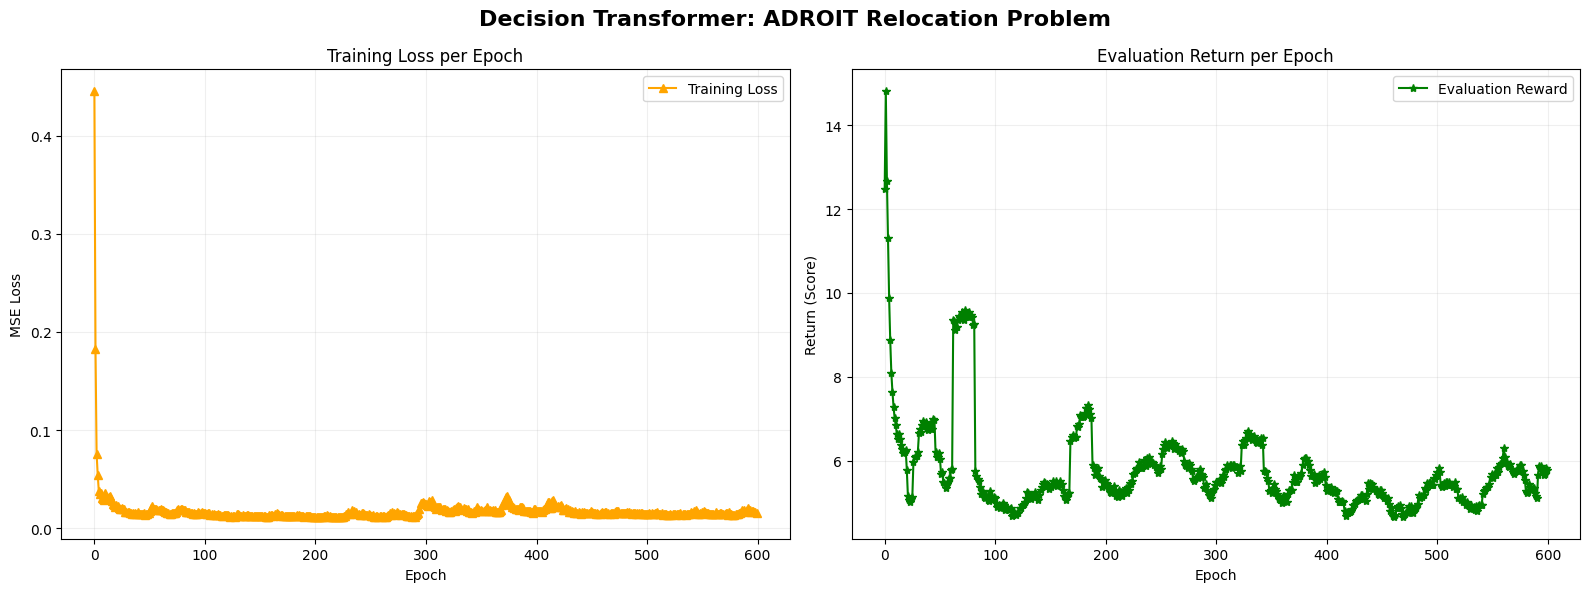

In [21]:
plot_losses(
    losses,
    rewards
)

### Visualizing the Agent
We can use `imageio` and `IPython.display.Video` to render the environment and watch the agent's behavior.

In [22]:
import imageio
from IPython.display import Video

def visualize_agent(model, target_return, state_mean, state_std, context_length=20, device="cuda", filename="agent_behavior.mp4"):
    render_env = dataset.recover_environment(render_mode="rgb_array")
    
    model.eval()
    state, _ = render_env.reset()
    state = (state - state_mean) / state_std
    max_ep_len = config["max_ep_length"]
    
    states = torch.zeros((1, max_ep_len, config["state_dim"]), dtype=torch.float32, device=device)
    actions = torch.zeros((1, max_ep_len, config["action_dim"]), dtype=torch.float32, device=device)
    returns_to_go = torch.zeros((1, max_ep_len, 1), dtype=torch.float32, device=device)
    timesteps = torch.arange(max_ep_len, dtype=torch.long, device=device).unsqueeze(0)
    
    states[0, 0] = torch.tensor(state, dtype=torch.float32, device=device)
    returns_to_go[0, 0] = torch.tensor([target_return], dtype=torch.float32, device=device)
    
    frames = []
    
    for t in range(max_ep_len):
        frames.append(render_env.render())
        
        start_t = max(0, t - context_length + 1)
        
        states_input = states[:, start_t:t+1]
        actions_input = actions[:, start_t:t+1]
        returns_input = returns_to_go[:, start_t:t+1]
        timesteps_input = timesteps[:, start_t:t+1]
        
        with torch.no_grad():
            action_preds = model(states_input, actions_input, returns_input, timesteps_input)
            action = action_preds[0, -1].cpu().numpy()
            
        next_state, reward, terminated, truncated, _ = render_env.step(action)
        next_state = (next_state - state_mean) / state_std
        
        if terminated or truncated:
            frames.append(render_env.render())
            break
            
        states[0, t+1] = torch.tensor(next_state, dtype=torch.float32, device=device)
        actions[0, t] = torch.tensor(action, dtype=torch.float32, device=device)
        returns_to_go[0, t+1] = torch.tensor([returns_to_go[0, t].item() - (reward / 1000.0)], dtype=torch.float32, device=device)
        
    render_env.close()
    
    # Save the captured frames as a video
    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved video to {filename}")
    
    # Display it in the notebook
    return Video(filename, embed=True)


In [23]:
# Load the best model weights saved by early stopping
try:
    model.load_state_dict(torch.load("best_decision_transformer.pth", weights_only=True))
    print("Loaded best model weights!")
except FileNotFoundError:
    print("No best model found, using current weights.")

# Visualize a single rollout
visualize_agent(model, target_return=5.4, state_mean=train_dataset.state_mean, state_std=train_dataset.state_std, context_length=K, device=device)


Loaded best model weights!
Saved video to agent_behavior.mp4


## Summary